In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

warnings.filterwarnings('ignore')

from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split,StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, RobustScaler, FunctionTransformer

from sklearn.metrics import roc_auc_score, f1_score, average_precision_score, classification_report, confusion_matrix, roc_curve
from sklearn.metrics import precision_recall_curve, auc,precision_score, recall_score, matthews_corrcoef,log_loss
from sklearn.compose import ColumnTransformer

from sklearn import set_config
from sklearn import svm,metrics
from sklearn.naive_bayes import GaussianNB #Naive bayes
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier #KNN
from sklearn.model_selection import KFold
from sklearn.compose import ColumnTransformer

from lightgbm import LGBMClassifier
import lightgbm as lgbm
from xgboost import XGBClassifier
import xgboost as xgb
from xgboost import plot_importance

#from tensorflow.keras import models, layers, Input

import sys
import os

project_root = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
if project_root not in sys.path:
    sys.path.append(project_root)
from scripts.Function_group import model_eval, ModelTuner
from scripts.feat_eng2 import Feature_Engineering
from scripts.feat_eng import apply_all

warnings.filterwarnings('ignore')
sns.set_theme(palette='pastel')

pd.set_option('display.max_rows', 50)
pd.set_option('display.max_columns', 50)

In [2]:
# 한글 폰트 출력
import matplotlib.font_manager as fm

# 설치된 폰트 출력
font_list = [font.name for font in fm.fontManager.ttflist]
font_list

plt.rcParams['font.family'] = 'Pretendard'

#싸이킷런에서 인코딩 후 데이터를 판다스 데이터 프레임으로 남기기
set_config(transform_output="pandas")

In [3]:
# 데이터 불러오기
merchant_df = pd.read_csv('../data/raw/big_data_set1_f.csv', encoding='cp949')
sale_df = pd.read_csv('../data/raw/big_data_set2_f.csv', encoding='cp949')
cust_df = pd.read_csv('../data/raw/big_data_set3_f.csv', encoding='cp949')

# Feature Engineering

In [79]:
FE = Feature_Engineering(merchant_df, sale_df, cust_df,9)
final_df = FE.run()


In [5]:
final_df

,매출금액 구간,매출건수 구간,유니크 고객 수 구간,객단가 구간,동일 업종 매출금액 비율,동일 업종 매출건수 비율,동일 업종 내 매출 순위 비율,동일 상권 내 매출 순위 비율,폐업 예측,최근 3개월 평균_매출금액 구간,최근 3개월 평균_매출건수 구간,최근 3개월 평균_유니크 고객 수 구간,최근 3개월 평균_객단가 구간,최근 3개월 평균_동일 업종 매출금액 비율,최근 3개월 평균_동일 업종 매출건수 비율,최근 3개월 평균_동일 업종 내 매출 순위 비율,최근 3개월 평균_동일 상권 내 매출 순위 비율,최근 6개월 평균_매출금액 구간,최근 6개월 평균_매출건수 구간,최근 6개월 평균_유니크 고객 수 구간,최근 6개월 평균_객단가 구간,최근 6개월 평균_동일 업종 매출금액 비율,최근 6개월 평균_동일 업종 매출건수 비율,최근 6개월 평균_동일 업종 내 매출 순위 비율,최근 6개월 평균_동일 상권 내 매출 순위 비율,1개월전_매출금액 구간,3개월전_매출금액 구간,6개월전_매출금액 구간,12개월전_매출금액 구간,1개월전_매출건수 구간,3개월전_매출건수 구간,6개월전_매출건수 구간,12개월전_매출건수 구간,1개월전_유니크 고객 수 구간,3개월전_유니크 고객 수 구간,6개월전_유니크 고객 수 구간,12개월전_유니크 고객 수 구간,1개월전_객단가 구간,3개월전_객단가 구간,6개월전_객단가 구간,12개월전_객단가 구간,업종,상권
1,4.0,4.0,4.0,4.0,43.7,23.3,34.1,0.0,0,4.0,4.0,4.0,4.0,51.350000,22.100000,33.950000,0.000000,4.0,4.0,4.0,4.0,51.350000,22.100000,33.950000,0.000000,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,3.0,NaN,NaN,NaN,육류,Unknown
2,4.0,4.0,4.0,3.0,52.2,22.3,34.8,0.0,0,4.0,4.0,4.0,3.0,51.633333,22.166667,34.233333,0.000000,4.0,4.0,4.0,3.0,51.633333,22.166667,34.233333,0.000000,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,4.0,NaN,NaN,NaN,육류,Unknown
3,5.0,4.0,4.0,3.0,32.5,15.1,36.9,0.0,0,4.0,4.0,4.0,3.0,42.800000,20.233333,35.266667,0.000000,4.0,4.0,4.0,3.0,46.850000,20.400000,34.900000,0.000000,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,3.0,3.0,NaN,NaN,육류,Unknown
4,4.0,4.0,4.0,3.0,50.1,23.3,37.7,0.0,0,4.0,4.0,4.0,3.0,44.933333,20.233333,36.466667,0.000000,4.0,4.0,4.0,3.0,47.500000,20.980000,35.460000,0.000000,5.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,3.0,4.0,NaN,NaN,육류,Unknown
5,4.0,4.0,4.0,3.0,55.5,24.1,38.2,0.0,0,4.0,4.0,4.0,3.0,46.033333,20.833333,37.600000,0.000000,4.0,4.0,4.0,3.0,48.833333,21.500000,35.916667,0.000000,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,4.0,4.0,NaN,NaN,3.0,3.0,NaN,NaN,육류,Unknown
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2263,3.0,1.0,1.0,5.0,202.4,332.7,5.7,28.6,0,3.0,1.0,1.0,5.0,222.300000,383.433333,5.800000,28.600000,2.0,1.0,1.0,5.0,246.283333,430.266667,5.616667,28.000000,3.0,2.0,3.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,6.0,5.0,6.0,카페,한양대
2264,2.0,1.0,1.0,5.0,240.0,407.6,5.6,28.3,0,3.0,1.0,1.0,5.0,209.666667,355.833333,5.733333,28.633333,2.0,1.0,1.0,5.0,244.466667,424.900000,5.666667,28.250000,3.0,2.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,5.0,5.0,6.0,카페,한양대
2265,2.0,1.0,1.0,5.0,275.2,449.2,5.4,27.8,0,2.0,1.0,1.0,5.0,239.200000,396.500000,5.566667,28.233333,2.0,1.0,1.0,5.0,241.350000,414.883333,5.666667,28.333333,2.0,3.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,5.0,5.0,6.0,카페,한양대
2266,3.0,1.0,1.0,6.0,200.1,360.9,5.6,27.1,0,2.0,1.0,1.0,5.0,238.433333,405.900000,5.533333,27.733333,2.0,1.0,1.0,5.0,230.366667,394.666667,5.666667,28.166667,2.0,3.0,2.0,3.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,5.0,5.0,6.0,5.0,카페,한양대


In [80]:
percent = 0.995
upper_bound1 = final_df['동일 업종 매출금액 비율'].quantile(percent)
upper_bound2 = final_df['동일 업종 매출건수 비율'].quantile(percent)
print(upper_bound1,upper_bound2)
final_df2 = final_df[(final_df['동일 업종 매출금액 비율']<=upper_bound1)&(final_df['동일 업종 매출건수 비율']<=upper_bound2)]


886.6140000000003 900.0340000000003


In [6]:
print(final_df['폐업 예측'].sum())

364


### 범주형 데이터 그룹화
- 업종 통합 시 sale_df의 업종관련 정보와의 차이 발생 가능

### is_closed 컬럼 생성

### 불필요 컬럼 제거

In [ ]:
# 피쳐 엔지니어링
#final_df = apply_all(merchant_df, sale_df, cust_df)

In [ ]:
# plt.figure(figsize=(15, 10))
# test = merged_df.copy()
# test.drop(['sale_amt_band', 'unique_customer_band', 'industry_sale_cnt_ratio', 'industry_sale_rank_pct'], axis=1, inplace=True)
# sns.heatmap(test.select_dtypes(exclude='object').corr(), annot=True, fmt='.1f', cmap='RdBu')
# plt.show()

In [ ]:
## ModelTuner 사용법

'''
#사용가능한 모델
logistic,knn,gnb,svc_linear,svc_rbf,xgb,lgbm

#모델 생성 및 데이터 입력
logistic_tuner = ModelTuner('logistic',X_train, X_test,y_train,y_test)
xgb_tuner = ModelTuner('xgb',X_train, X_test,y_train,y_test)

#모델 튜닝 및 평가
#tune_evals은 생략 가능
logistic_tuner.run(tune_evals=50)

#튜닝된 모델
logistic_tuner.final_model()

#최적의 파라미터
logistic_tuner.best_params()

#모델 성능 지표
logistic_tuner.evaluate()

'''

### 인코딩

In [53]:
final_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2155 entries, 1 to 2267
Data columns (total 43 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   매출금액 구간                     2155 non-null   float64
 1   매출건수 구간                     2155 non-null   float64
 2   유니크 고객 수 구간                 2155 non-null   float64
 3   객단가 구간                      2155 non-null   float64
 4   동일 업종 매출금액 비율               2155 non-null   float64
 5   동일 업종 매출건수 비율               2155 non-null   float64
 6   동일 업종 내 매출 순위 비율            2155 non-null   float64
 7   동일 상권 내 매출 순위 비율            2155 non-null   float64
 8   폐업 예측                       2155 non-null   int64  
 9   최근 3개월 평균_매출금액 구간           2155 non-null   float64
 10  최근 3개월 평균_매출건수 구간           2155 non-null   float64
 11  최근 3개월 평균_유니크 고객 수 구간       2155 non-null   float64
 12  최근 3개월 평균_객단가 구간            2155 non-null   float64
 13  최근 3개월 평균_동일 업종 매출금액 비율     2155 non-n

In [70]:
y = final_df['폐업 예측']
X = final_df.drop(columns = ['폐업 예측'])


In [71]:
#학습, 테스트 데이터 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#numerical_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(exclude=['int64', 'float64']).columns
numerical_features = ['동일 업종 매출금액 비율','동일 업종 매출건수 비율','최근 3개월 평균_동일 업종 매출금액 비율','최근 3개월 평균_동일 업종 매출건수 비율',
 '최근 6개월 평균_동일 업종 매출금액 비율','최근 6개월 평균_동일 업종 매출건수 비율']


preprocessor = ColumnTransformer(
    transformers=[
        ('num', FunctionTransformer(np.log1p), numerical_features), # 숫자형 컬럼은 StandardScaling
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)  # 범주형 컬럼은 OneHotEncoding
    ],remainder='passthrough')

#주의: 테스트 셋에서 학습 데이터에 없는 값들이 무시될 수 있음 handle_unknown='ignore' 없는 것도 적용해 볼것
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)


X_tr, X_val, y_tr, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)#학습, 검증 데이터 셋 분리

In [72]:
X_train.shape

(1724, 64)

### Logistic Regression

In [ ]:
#Logistic Regression
model = LogisticRegression()
model.fit(X_train,y_train)

model_eval(model,"Logistic Regression",X_test,y_test)

In [ ]:
ModelTuner('logistic',X_train, X_test,y_train,y_test).run()

--- logistic 모델의 하이퍼파라미터 튜닝 시작 ---
 30%|███       | 15/50 [00:26<01:28,  2.53s/trial, best loss: -0.5842857142857143]

### Gaussian Naive Bayes

In [ ]:
# Gaussian Naive Bayes
model=GaussianNB()
model.fit(X_train,y_train)

#가우시안은 X 데이터에 .toarray() 붙이기
model_eval(model,"Gaussian Naive Bayes",X_test,y_test)

In [ ]:
ModelTuner('gnb',X_train, X_test,y_train,y_test).run()

### KNN(K-Nearest Neighbours)

In [ ]:
#K-Nearest Neighbours(KNN)
model=KNeighborsClassifier() 
model.fit(X_train,y_train)

model_eval(model,"K-Nearest Neighbours",X_test,y_test)

In [ ]:
#KNN 모델에서 N-neighbours 수를 늘려가며 정확도를 계산
a_index=list(range(1,11))
a=pd.Series()
x=[0,1,2,3,4,5,6,7,8,9,10]
for i in list(range(1,11)):
    model=KNeighborsClassifier(n_neighbors=i) 
    model.fit(X_train,y_train)
    prediction=model.predict(X_test)
    score = pd.Series([metrics.accuracy_score(prediction,y_test)])
    a = pd.concat([a, score], ignore_index=True)
plt.plot(a_index, a)
plt.xticks(x)
fig=plt.gcf()
fig.set_size_inches(12,6)
plt.show()
print('Accuracies for different values of n are:',a.values,'with the max value as ',a.values.max())

In [ ]:
ModelTuner('knn',X_train, X_test,y_train,y_test).run()

### Support Vector Machine

In [ ]:
#Linear Support Vector Machine(linear-SVM)
model=svm.SVC(probability=True,kernel='linear',C=0.1,gamma=0.1)
model.fit(X_train,y_train)

model_eval(model,"Linear Support Vector Machine",X_test,y_test)

In [ ]:
ModelTuner('svc_linear',X_train, X_test,y_train,y_test).run()

In [ ]:
#Radial Support Vector Machines(rbf-SVM)
model=svm.SVC(probability=True,kernel='rbf',C=1,gamma=0.1)
model.fit(X_train,y_train)

model_eval(model,"Radial Support Vector Machines",X_test,y_test)

In [ ]:
ModelTuner('svc_rbf',X_train, X_test,y_train,y_test).run()

### Light Gradient Boosting Machine

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Using sparse features with CUDA is currently not supported.
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Info] Number of positive: 238, number of negative: 1141
[LightGBM] [Info] Total Bins 3306
[LightGBM] [Info] Number of data points in the train set: 1379, number of used features: 62
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
Training until validation scores don't improve for 50

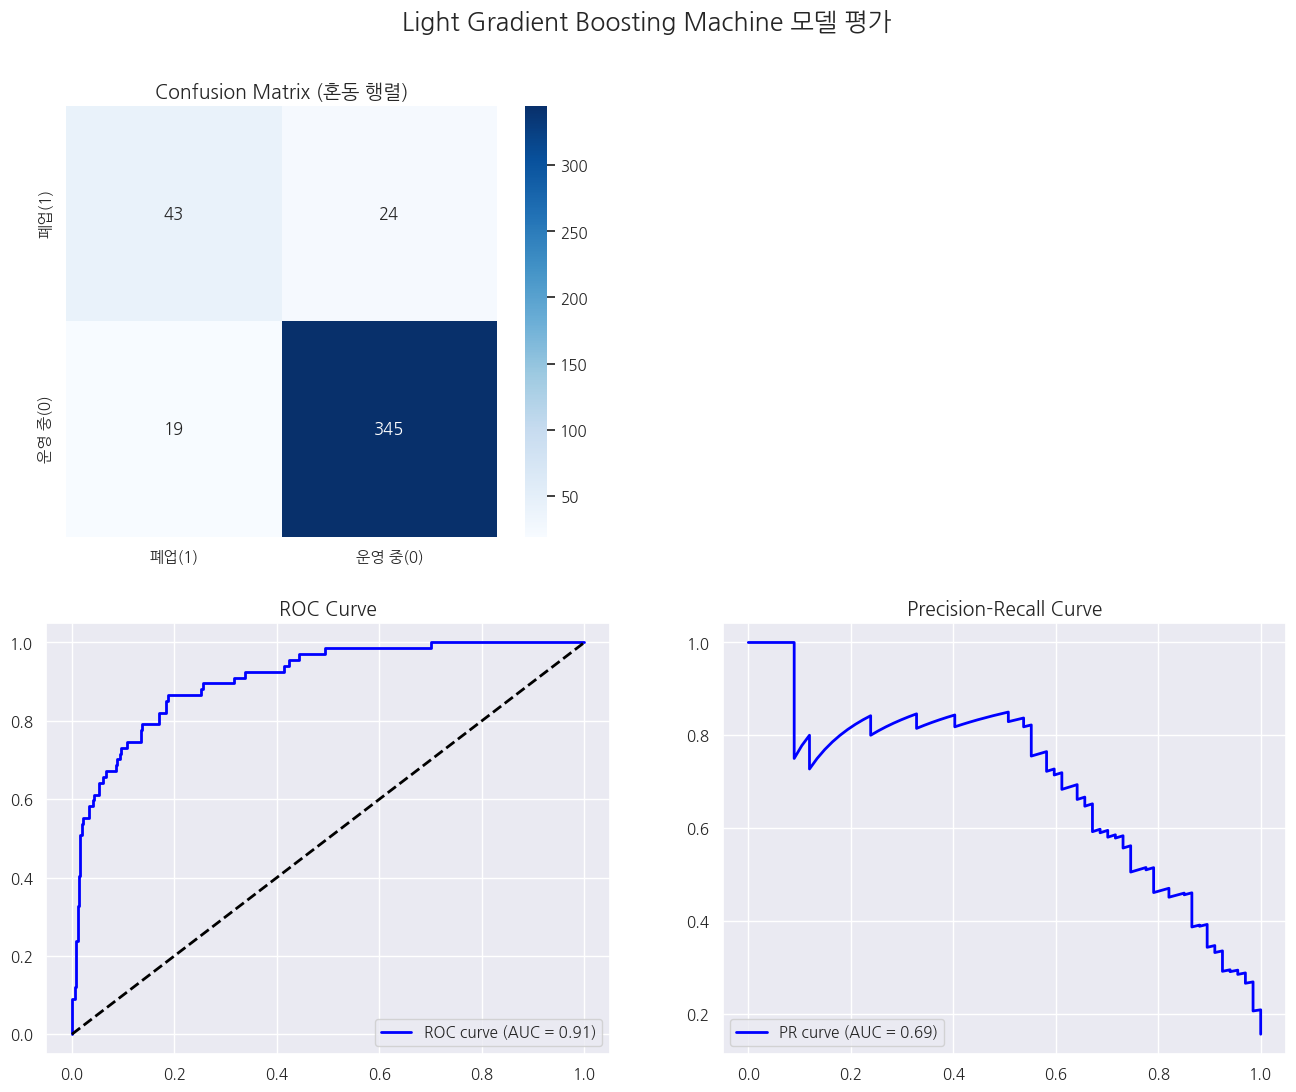

In [89]:
#GPU 사용안되면 device='cuda' 지우기
lgb_model = LGBMClassifier(
    device='cuda',
    n_estimators=500,
    learning_rate=0.05,
    class_weight = "balanced", #가중치추가
    subsample=0.8,
    colsample_bytree=0.8,
    min_gain_to_split=0.05,
    random_state=42,
)

lgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)]
    ,callbacks=[lgbm.early_stopping(stopping_rounds=50, verbose=-1)]
)

model_eval(lgb_model,"Light Gradient Boosting Machine",X_test,y_test)

In [ ]:
ModelTuner('lgbm',X_train, X_test,y_train,y_test).run()

### Exreme Gradient Boosting

--- Exreme Gradient Boosting 모델 평가 ---
정확도(Accuracy): 0.8886
정밀도(Precision): 0.6418
재현율(Recall): 0.6418
F1 점수(F1 Score): 0.6418
매튜 상관 계수(MCC): 0.5759



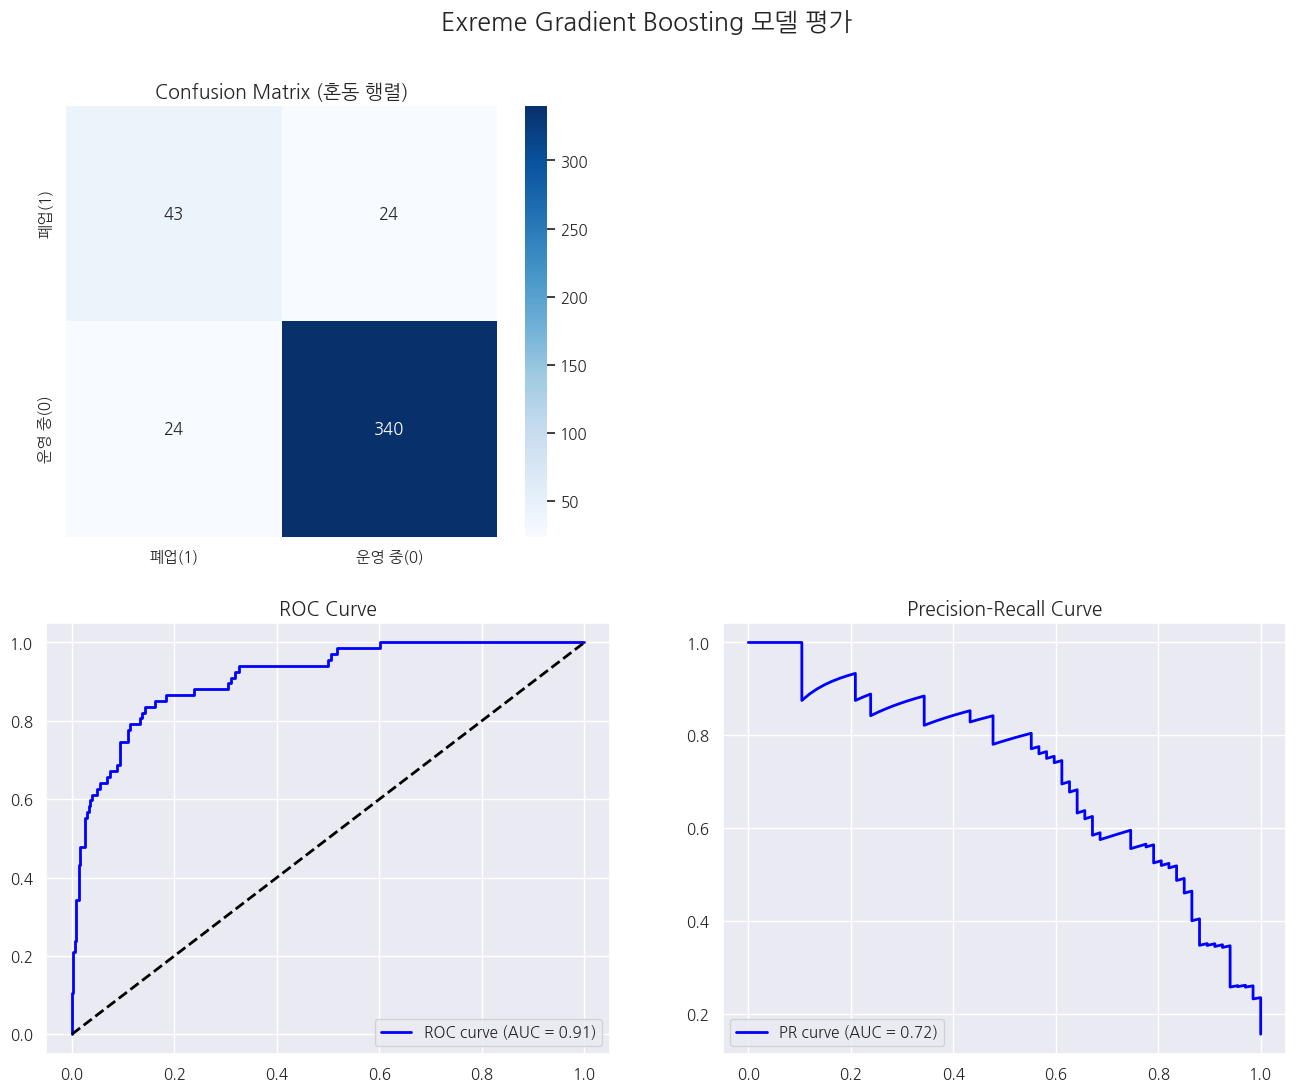

In [88]:
#GPU 사용안되면 tree_method = "hist", device = "cuda" 지우기
xgb_model = XGBClassifier(tree_method = "hist", device = "cuda",
    n_estimators=500,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=(len(y_train) - sum(y_train)) / sum(y_train),
    random_state=42,
    n_jobs=-1,
    use_label_encoder=False,
    early_stopping_rounds=50                      
)

xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)], verbose=False
)

model_eval(xgb_model,"Exreme Gradient Boosting",X_test,y_test)

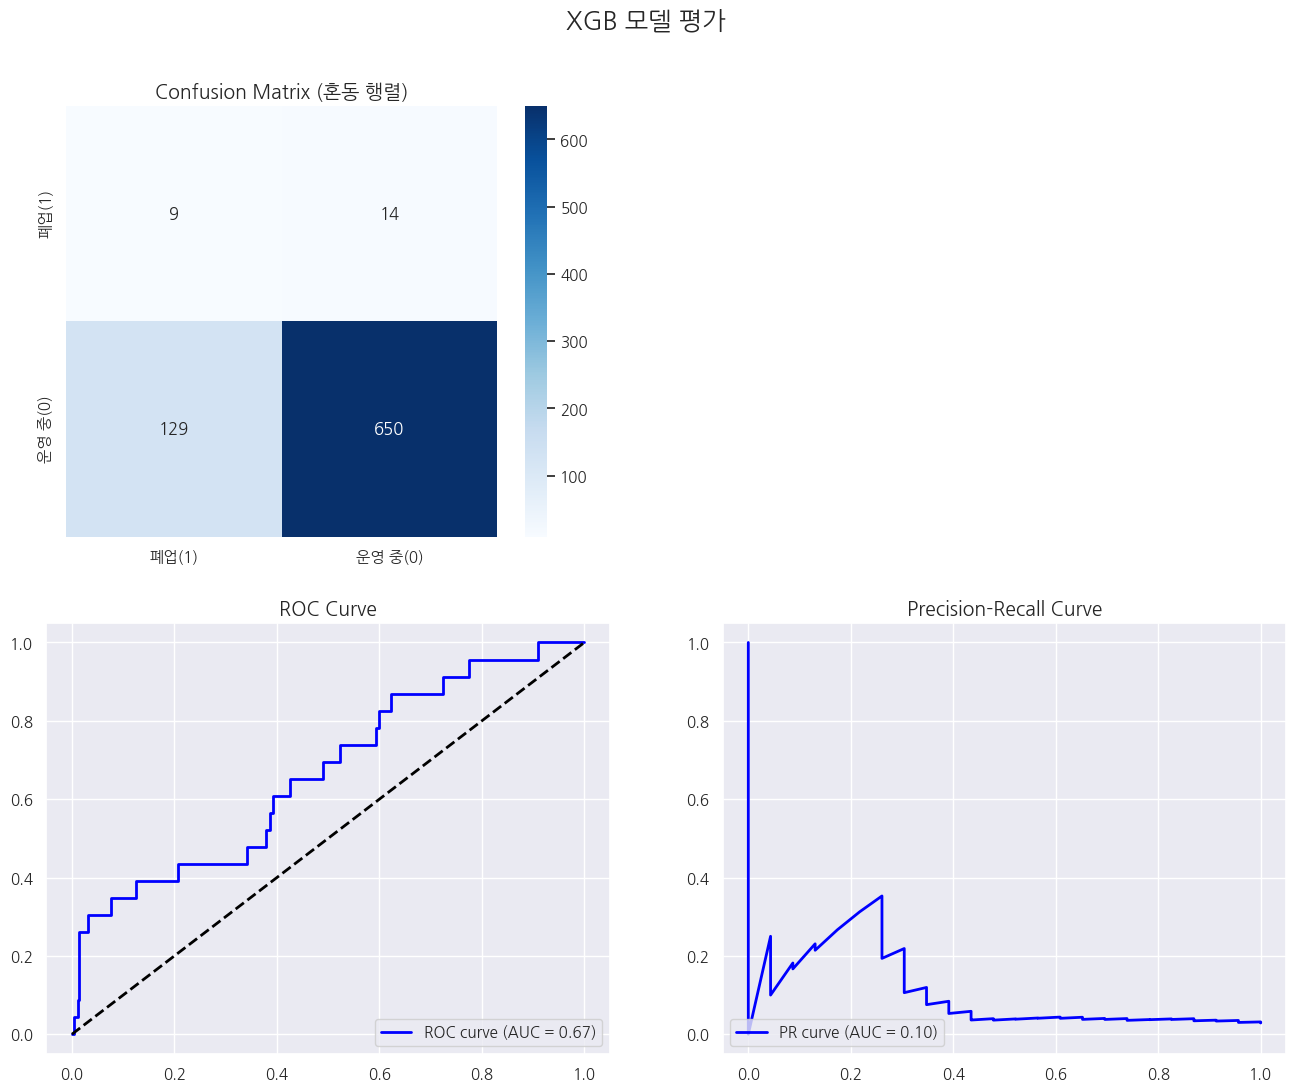

In [ ]:
ModelTuner('xgb',X_train, X_test,y_train,y_test).run()

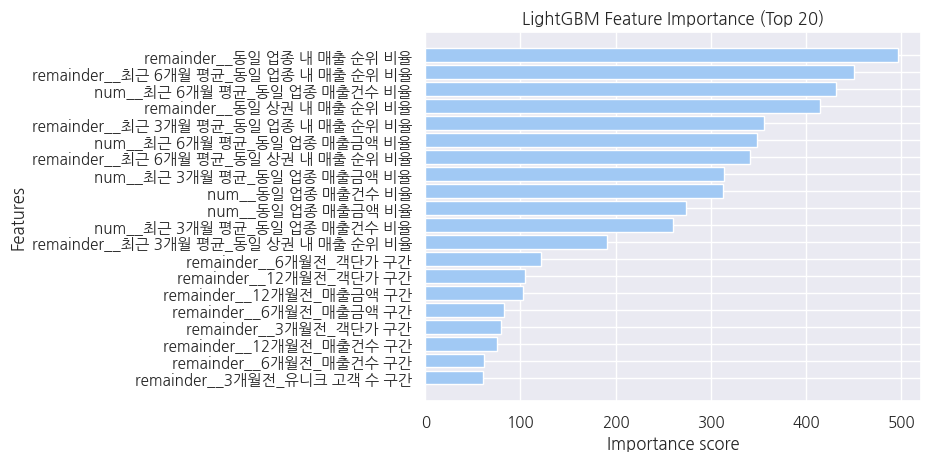

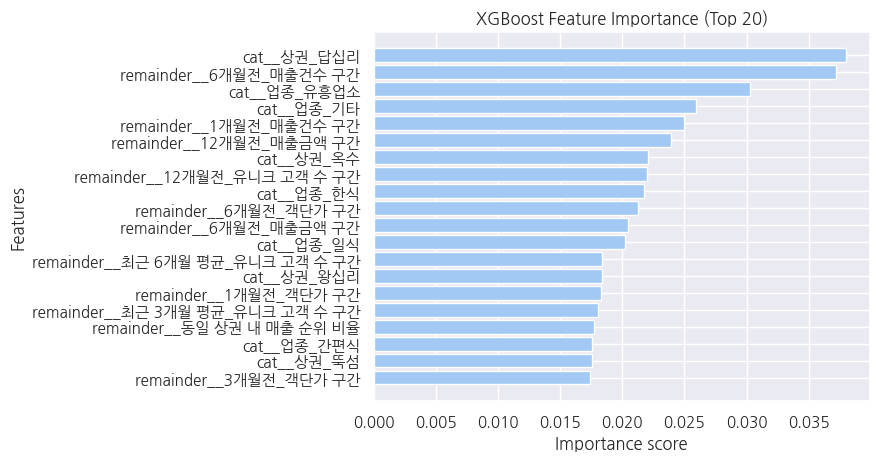

In [90]:
def plot_feature_importance(model_name, features, importances, top_n=20):
    idx = np.argsort(importances)[::-1][:top_n]
    plt.barh(np.array(features)[idx][::-1], np.array(importances)[idx][::-1])
    plt.title(f"{model_name} Feature Importance (Top {top_n})")
    plt.xlabel("Importance score")
    plt.ylabel("Features")
    plt.show()


# LightGBM
fi_lgb = lgb_model.feature_importances_
plot_feature_importance("LightGBM", X_val.columns, fi_lgb)

# XGBoost
fi_xgb = xgb_model.feature_importances_  # numpy array
plot_feature_importance("XGBoost", X_val.columns, fi_xgb)

# CatBoost
# fi_cat = cat_model.get_feature_importance()
# plot_feature_importance("CatBoost", X_val.columns, fi_cat)

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
                                  feature  importance
35            remainder__동일 상권 내 매출 순위 비율    0.087446
51               remainder__12개월전_매출금액 구간    0.078199
34            remainder__동일 업종 내 매출 순위 비율    0.063636
41  remainder__최근 3개월 평균_동일 상권 내 매출 순위 비율    0.045118
63                remainder__12개월전_객단가 구간    0.035334
1                      num__동일 업종 매출건수 비율    0.031526
62                 remainder__6개월전_객단가 구간    0.030303
54                remainder__6개월전_매출건수 구간    0.028983
4            num__최근 6개월 평균_동일 업종 매출금액 비율    0.027922
0                      num__동일 업종 매출금액 비율    0.024506


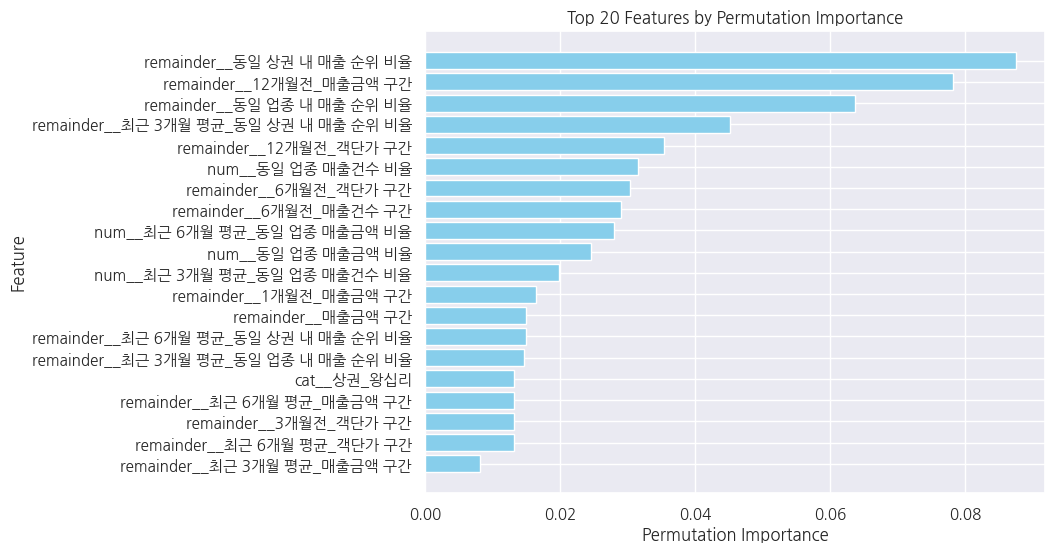

In [91]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    lgb_model, X_val, y_val,
    scoring="f1",
    n_repeats=1,
    random_state=42,
    n_jobs=-1
    
)

import pandas as pd

fi = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result.importances_mean
}).sort_values(by="importance", ascending=False)

print(fi.head(10))

top_features = fi.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features["feature"], top_features["importance"], color="skyblue")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")
plt.gca().invert_yaxis() 
plt.show()

                                  feature  importance
3            num__최근 3개월 평균_동일 업종 매출건수 비율    0.081818
51               remainder__12개월전_매출금액 구간    0.056566
34            remainder__동일 업종 내 매출 순위 비율    0.046104
63                remainder__12개월전_객단가 구간    0.029437
4            num__최근 6개월 평균_동일 업종 매출금액 비율    0.028247
41  remainder__최근 3개월 평균_동일 상권 내 매출 순위 비율    0.026263
54                remainder__6개월전_매출건수 구간    0.026263
35            remainder__동일 상권 내 매출 순위 비율    0.023260
47  remainder__최근 6개월 평균_동일 상권 내 매출 순위 비율    0.021071
62                 remainder__6개월전_객단가 구간    0.015780


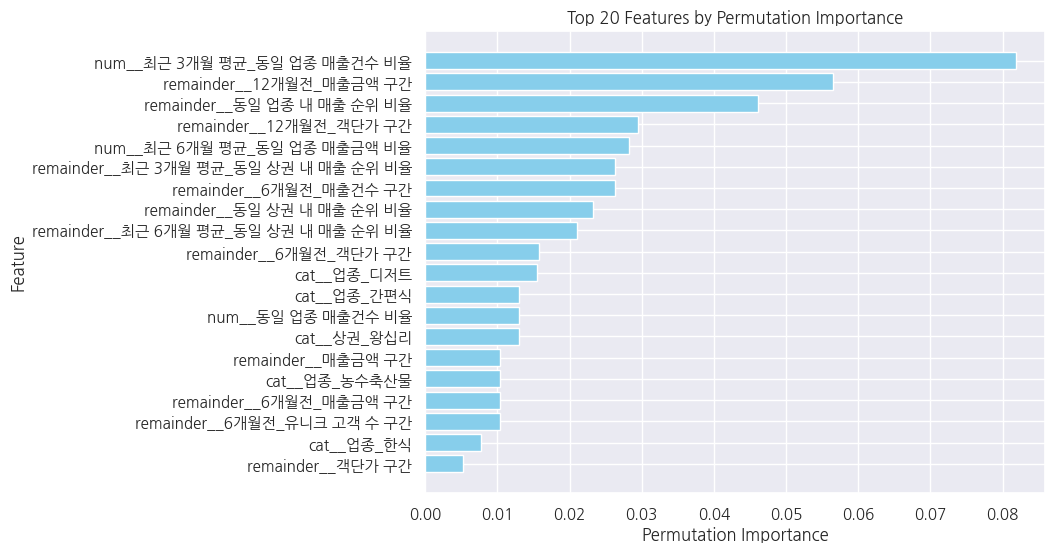

[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_split=0.05
[LightGBM] [Warning] min_gain_to_split is set=0.05, min_split_gain=0.0 will be ignored. Current value: min_gain_to_spl

In [92]:
result_xgb = permutation_importance(
    xgb_model, X_val, y_val,
    scoring="f1",
    n_repeats=1,
    random_state=42,
    n_jobs=-1
     
)

fi_xgb = pd.DataFrame({
    "feature": X_val.columns,
    "importance": result_xgb.importances_mean
}).sort_values(by="importance", ascending=False)

print(fi_xgb.head(10))

top_features_xgb = fi_xgb.head(20)

plt.figure(figsize=(8, 6))
plt.barh(top_features_xgb["feature"], top_features_xgb["importance"], color="skyblue")
plt.xlabel("Permutation Importance")
plt.ylabel("Feature")
plt.title("Top 20 Features by Permutation Importance")
plt.gca().invert_yaxis() 
plt.show()

## 비지도 학습

In [81]:
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, silhouette_samples
from sklearn.preprocessing import FunctionTransformer

final_df_prc = final_df2.fillna(0)

numerical_features = final_df.select_dtypes(include=['int64', 'float64']).columns
categorical_features = final_df.select_dtypes(exclude=['int64', 'float64']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features), # 숫자형 컬럼은 StandardScaling
        ('cat', OneHotEncoder(handle_unknown='ignore',sparse_output=False), categorical_features)  # 범주형 컬럼은 OneHotEncoding
    ])

final_df_prc = preprocessor.fit_transform(final_df_prc)

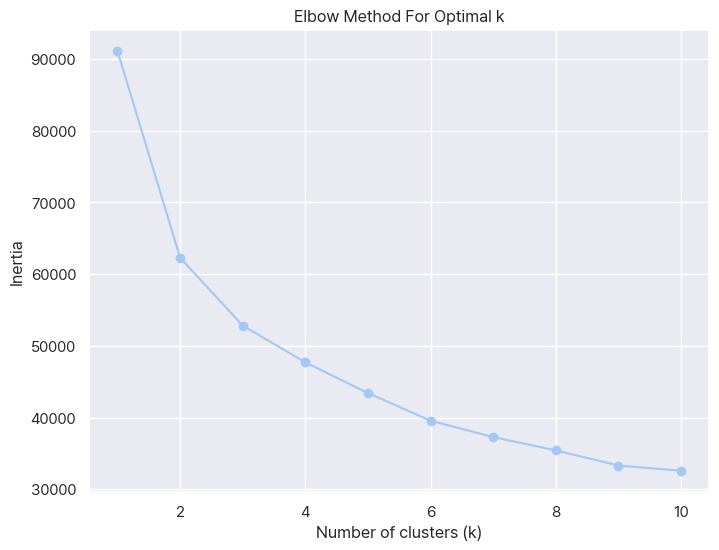

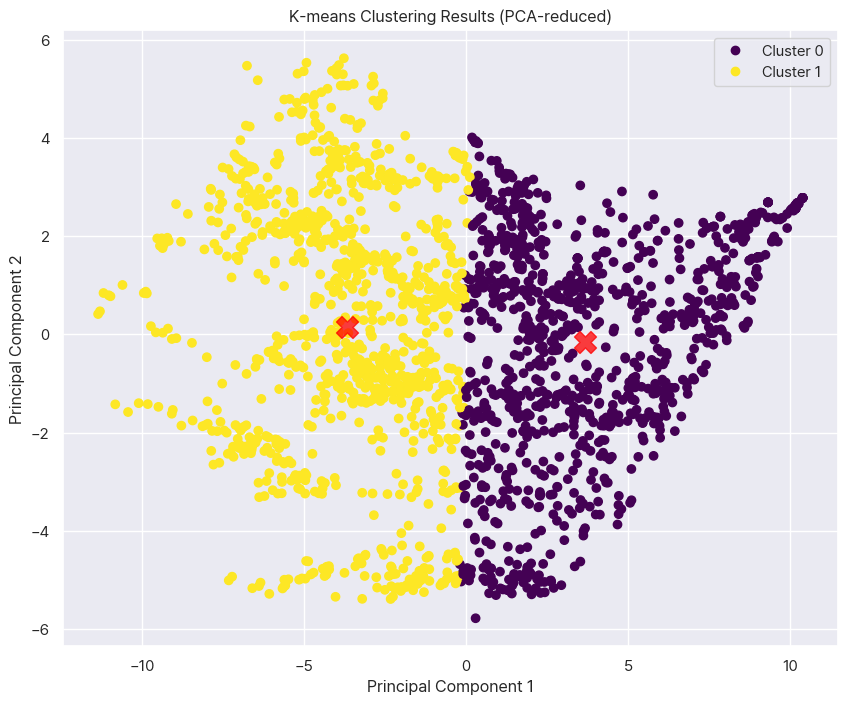

In [82]:
# k-means clustering

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(final_df_prc)
    inertia.append(kmeans.inertia_)

# Elbow Method 
plt.figure(figsize=(8, 6))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method For Optimal k')
plt.show()

optimal_k = 2
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
cluster_labels = kmeans.fit_predict(final_df_prc)

#PCA를 사용하여 2차원으로 차원 축소 후 시각화
#클러스터의 중심을 빨간색 'X'로 표시
pca = PCA(n_components=2)
principal_components = pca.fit_transform(final_df_prc)


plt.figure(figsize=(10, 8))
scatter = plt.scatter(principal_components.iloc[:, 0], principal_components.iloc[:, 1], c=cluster_labels, cmap='viridis', marker='o')

centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers.iloc[:, 0], centers.iloc[:, 1], c='red', s=250, alpha=0.75, marker='X')
plt.title('K-means Clustering Results (PCA-reduced)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(handles=scatter.legend_elements()[0], labels=[f'Cluster {i}' for i in range(optimal_k)])
plt.grid(True)
plt.show()

In [75]:
len((principal_components.iloc[:, 0]))

2133

For n_clusters = 2, the average silhouette_score is : 0.5262


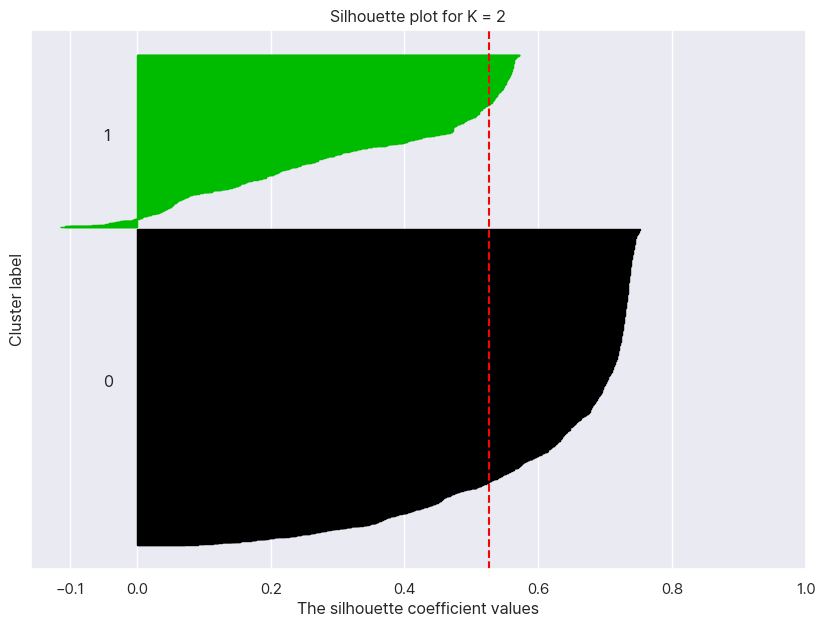

For n_clusters = 3, the average silhouette_score is : 0.4698


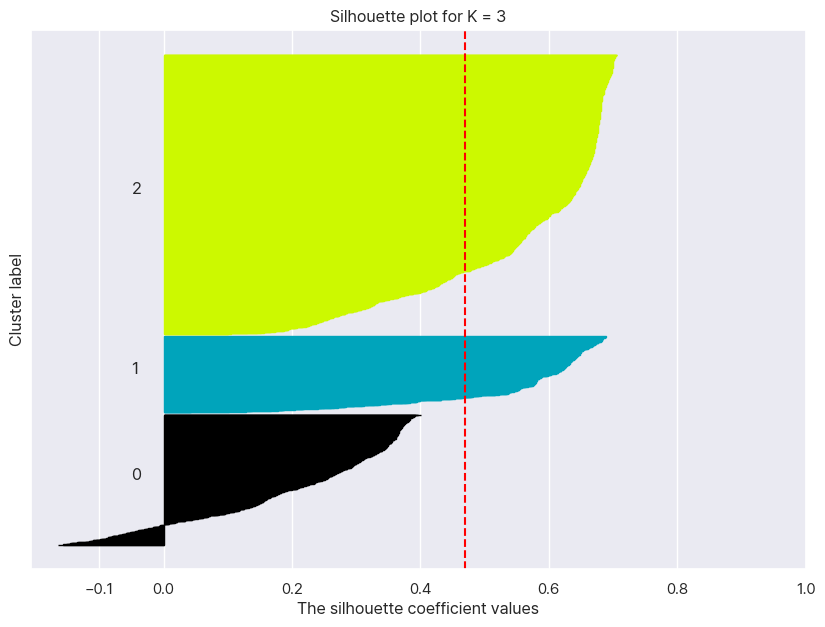

For n_clusters = 4, the average silhouette_score is : 0.4981


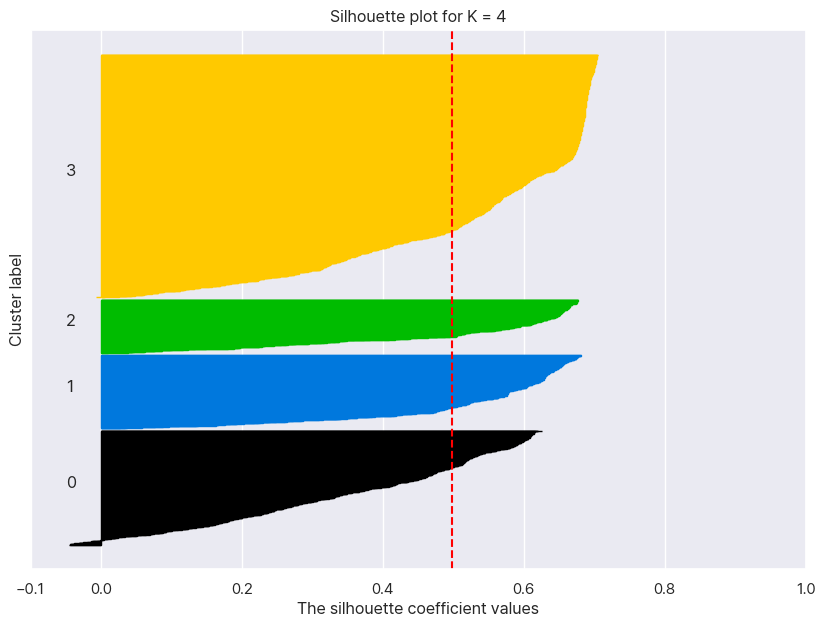

For n_clusters = 5, the average silhouette_score is : 0.4300


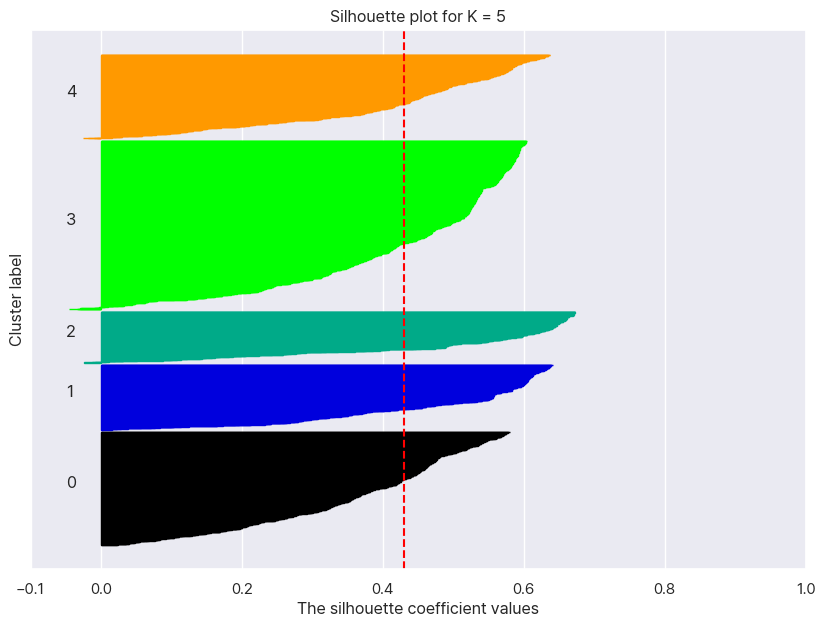

For n_clusters = 6, the average silhouette_score is : 0.4495


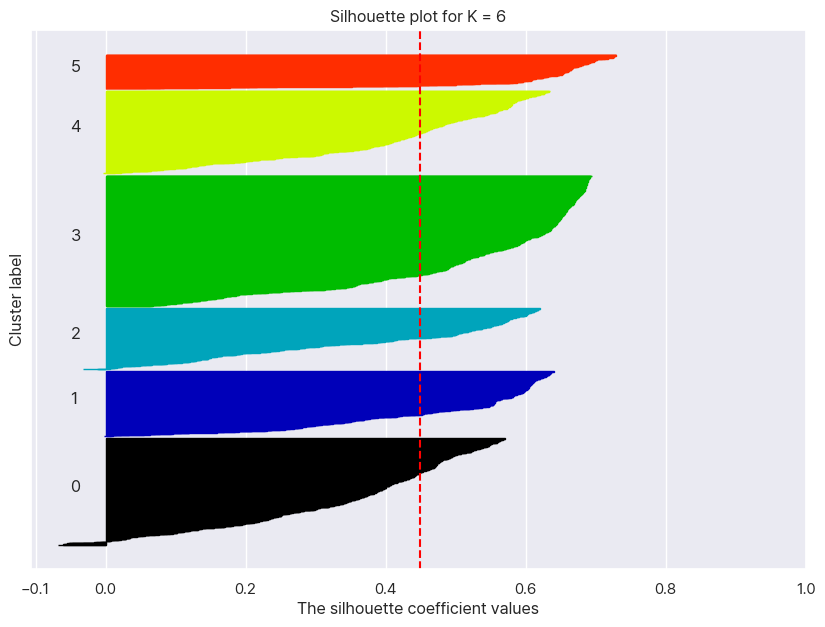

For n_clusters = 7, the average silhouette_score is : 0.4068


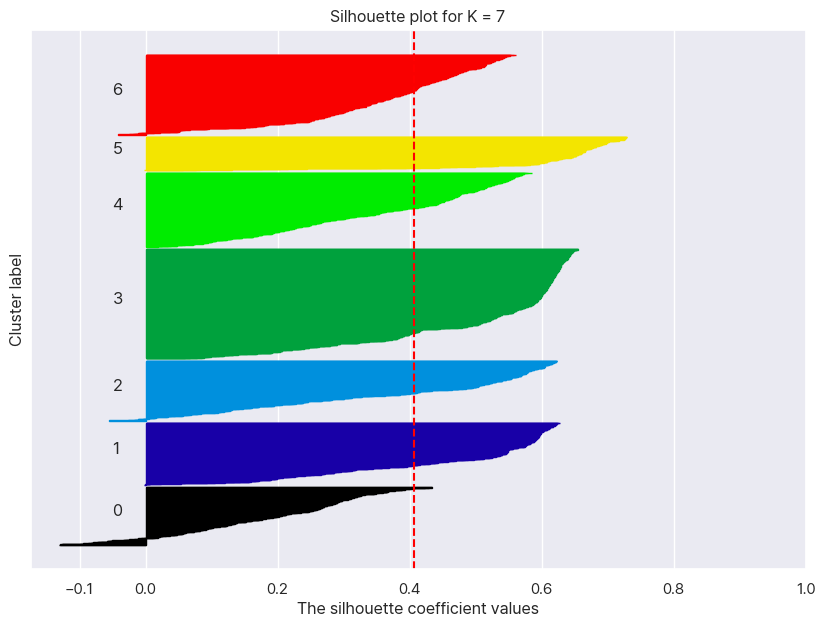

For n_clusters = 8, the average silhouette_score is : 0.3954


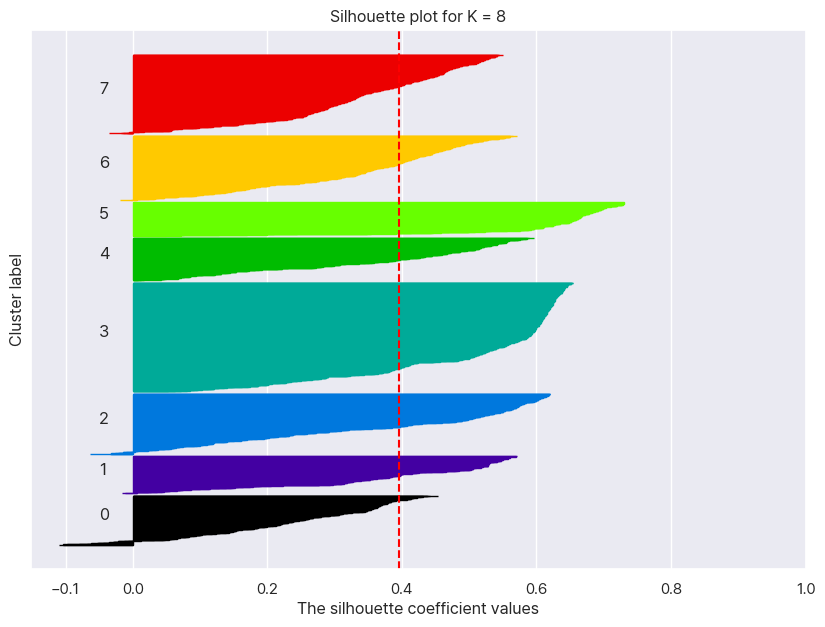

For n_clusters = 9, the average silhouette_score is : 0.3837


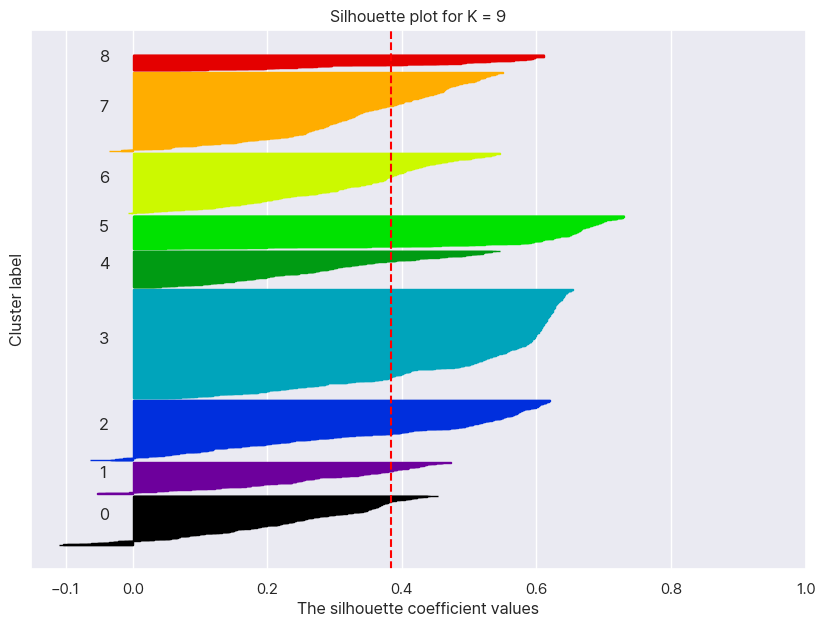

For n_clusters = 10, the average silhouette_score is : 0.3669


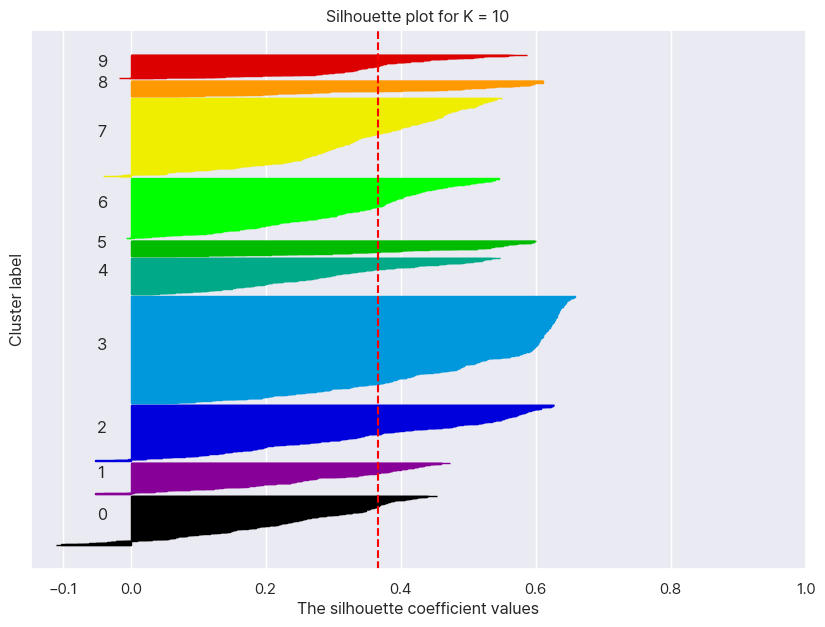

In [76]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_samples, silhouette_score


for k in range(2, 11):

    fig, ax = plt.subplots(1, 1)
    fig.set_size_inches(10, 7)


    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto').fit(final_df_prc)
    silhouette_vals = silhouette_samples(final_df_prc, kmeans.labels_)
    avg_silhouette_score = silhouette_score(final_df_prc, kmeans.labels_)
    print(f"For n_clusters = {k}, the average silhouette_score is : {avg_silhouette_score:.4f}")
    
    y_lower = 10  
    

    for c_num in range(k):

        cluster_silhouette_vals = silhouette_vals[kmeans.labels_ == c_num]
        cluster_silhouette_vals.sort()
        
        cluster_size = cluster_silhouette_vals.shape[0]
        y_upper = y_lower + cluster_size
        color = cm.nipy_spectral(float(c_num) / k)
        
        ax.barh(range(y_lower, y_upper), 
                cluster_silhouette_vals, 
                facecolor=color, 
                edgecolor=color,
                height=1.0)
        
        ax.text(-0.05, y_lower + 0.5 * cluster_size, str(c_num))
        y_lower = y_upper + 10  # 다음 클러스터와의 여백

    ax.set_title(f"Silhouette plot for K = {k}")
    ax.set_xlabel("The silhouette coefficient values")
    ax.set_ylabel("Cluster label")


    ax.axvline(x=avg_silhouette_score, color="red", linestyle="--")
    
    ax.set_yticks([])  
    ax.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    plt.show()

In [83]:
final_df_prc['cluster'] = cluster_labels

# 각 클러스터별로 모든 피쳐의 평균값을 계산하여 비교
cluster_feature_means = final_df_prc.groupby('cluster').mean()

# 보기 쉽게 행과 열을 전환(.T)하여 출력
print(cluster_feature_means.T)

cluster                    0         1
num__매출금액 구간        0.758531 -0.763526
num__매출건수 구간        0.710713 -0.715393
num__유니크 고객 수 구간    0.736538 -0.741388
num__객단가 구간         0.198103 -0.199407
num__동일 업종 매출금액 비율 -0.628403  0.632541
...                      ...       ...
cat__상권_신금호         0.024299  0.056444
cat__상권_옥수          0.011215  0.010348
cat__상권_왕십리         0.086916  0.105362
cat__상권_한양대         0.066355  0.139229
cat__상권_행당          0.044860  0.008467

[65 rows x 2 columns]


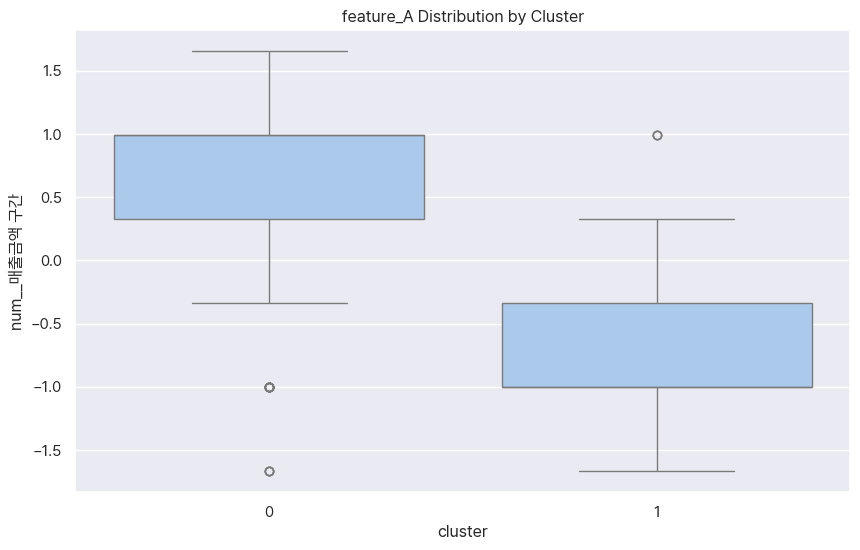

In [85]:
plt.figure(figsize=(10, 6))
sns.boxplot(x='cluster', y='num__매출금액 구간', data=final_df_prc)
plt.title('feature_A Distribution by Cluster')
plt.show()

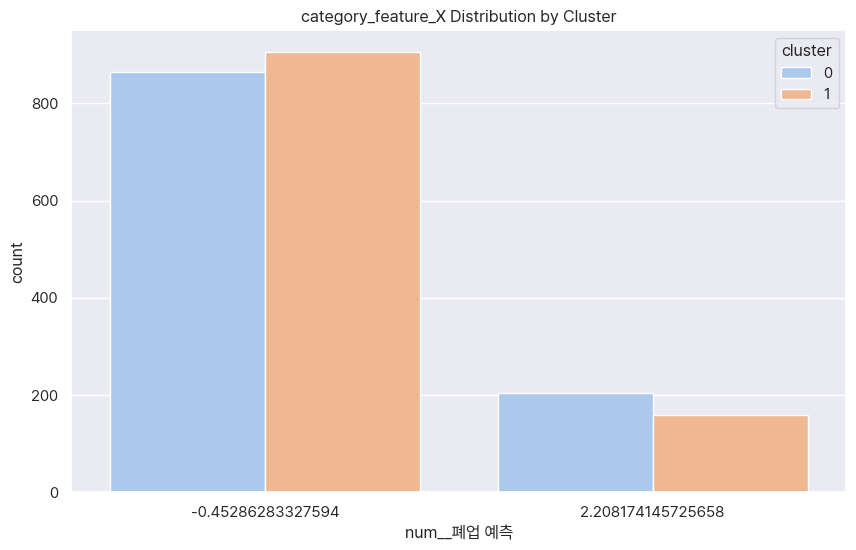

In [86]:
plt.figure(figsize=(10, 6))
sns.countplot(x='num__폐업 예측', hue='cluster', data=final_df_prc)
plt.title('category_feature_X Distribution by Cluster')
plt.show()

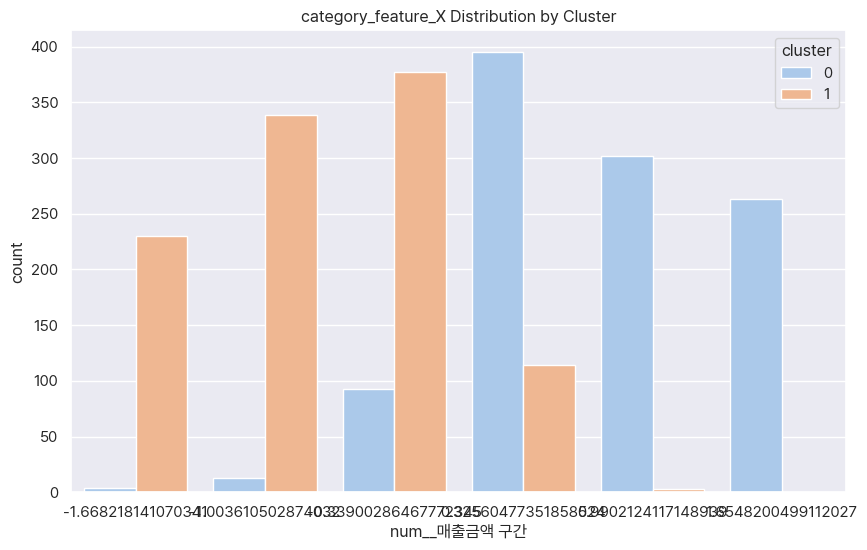

In [87]:
plt.figure(figsize=(10, 6))
sns.countplot(x='num__매출금액 구간', hue='cluster', data=final_df_prc)
plt.title('category_feature_X Distribution by Cluster')
plt.show()

### Deep Learning